# Разведочный анализ: очистка данных и решения по ним

**Управленческий вопрос.** Данные пришли — можно ли на них опираться, и что
они говорят о процессе?

Разведочный анализ — это работа до расчётов: понять, что в выгрузке лежит,
чему в ней можно верить и какие вопросы к ней вообще осмысленны. Тетрадь
идёт двумя частями:

1. **Очистка данных** — что это такое, какие дефекты бывают и сколько стоит
   пропустить проверку.
2. **Решения по данным** — какие вопросы задаются запросом и как ответ
   превращается в управленческое действие.

Данные те же, что в кейсе конвейера: заявки, события этапов, решения, выдачи.
Каждое число ниже воспроизводится запросом на вашем стенде.

In [1]:
import sys
sys.path.append("..")

from tools.sqlcell import setup
from tools.compare import запрос          # тот же SQL, но результат таблицей pandas

setup()

import matplotlib
import matplotlib.pyplot as plt

%matplotlib inline
matplotlib.rcParams["font.size"] = 11
matplotlib.rcParams["figure.figsize"] = (9, 3.6)

ACC, WARN, INK = "#20BA72", "#E4572E", "#2E3641"


def оформить(ax, заголовок, x=None, y=None):
    """Единое оформление: заголовок, подписи осей, лишние рамки убраны."""
    ax.set_title(заголовок, fontsize=12.5, pad=12, fontweight="bold", color=INK)
    if x:
        ax.set_xlabel(x, fontsize=10.5)
    if y:
        ax.set_ylabel(y, fontsize=10.5)
    ax.spines[["top", "right"]].set_visible(False)
    ax.set_axisbelow(True)

База «bank_training» на связи: PostgreSQL 16.15 (Debian 16.15-1.pgdg13+2) on x86_64-pc-linux-gnu


объект,тип
v_applications_clean,VIEW
v_initiative_cashflow,VIEW
v_initiative_fact_vs_plan,VIEW
v_initiative_npv,VIEW
v_initiative_plan,VIEW
v_pipeline_stage_sla,VIEW
v_portfolio_npv,VIEW
v_stage_events_clean,VIEW
initiative_fact,BASE TABLE
initiative_passport,BASE TABLE


## Часть 1. Очистка данных

### Что это такое

Очистка — не косметика перед расчётом, а решение о том, какие строки считаются
событиями процесса, а какие — следом работы систем. Решение это управленческое:
отбросили тестовые заявки — изменилась конверсия, оставили незакрытые этапы —
изменился средний срок. Поэтому правило чистки формулируется явно, записывается
в одном месте и применяется всеми одинаково.

Дефекты выгрузки складываются в четыре группы, и проверять их стоит именно
в этом порядке:

| Группа | Что ищем | Чем грозит |
|---|---|---|
| Повторы | одна и та же строка два раза | завышенные объёмы и доли |
| Служебные записи | тесты, отладка, техклиенты | смещённые показатели |
| Невозможные значения | выход раньше входа, пустые обязательные поля | отрицательные сроки, деление на ноль |
| Разрывы между источниками | заявка есть, решения нет | «потерянные» заявки в воронке |

### Осмотр: объём и границы

Первый запрос к незнакомым данным — всегда про то, сколько строк и за какой
период. Без этого любое число дальше повисает в воздухе.

In [2]:
%%sql
SELECT
    count(*)                        AS "Строк в выгрузке",
    count(DISTINCT application_id)  AS "Уникальных заявок",
    min(submitted_at)::date         AS "Первая заявка",
    max(submitted_at)::date         AS "Последняя заявка"
FROM raw_applications

Строк в выгрузке,Уникальных заявок,Первая заявка,Последняя заявка
3 672,3 600,2025-01-06,2025-08-03


Строк больше, чем уникальных заявок, — значит, повторы есть. Дальше — что
в выгрузке пусто: пропуск в обязательном поле означает либо сбой передачи,
либо то, что событие ещё не наступило, и это разные вещи.

In [3]:
%%sql
SELECT
    count(*)                                             AS "Всего строк",
    count(*) FILTER (WHERE amount_requested IS NULL)     AS "Без суммы",
    count(*) FILTER (WHERE channel IS NULL)              AS "Без канала",
    count(*) FILTER (WHERE region IS NULL)               AS "Без региона",
    count(*) FILTER (WHERE submitted_at IS NULL)         AS "Без времени подачи"
FROM raw_applications

Всего строк,Без суммы,Без канала,Без региона,Без времени подачи
3 672,0,0,0,0


### Повторы

In [4]:
%%sql
SELECT application_id AS "Заявка", count(*) AS "Строк в выгрузке"
FROM raw_applications
GROUP BY application_id
HAVING count(*) > 1
ORDER BY 2 DESC, 1
LIMIT 5

Заявка,Строк в выгрузке
APP-201250,3
APP-201605,3
APP-202134,3
APP-202971,3
APP-202976,3


### Служебные записи

Тестовые заявки создаются при отладке интеграций и живут в тех же таблицах,
что и настоящие. В учебной базе они помечены явно — в жизни признак чаще всего
приходится собирать по косвенным следам: технический клиент, нулевая сумма,
подозрительно круглое время.

In [5]:
%%sql
SELECT
    count(*) FILTER (WHERE is_test)                   AS "Помечены как тестовые",
    count(*) FILTER (WHERE client_id = 'CL-TEST')     AS "Технический клиент",
    count(DISTINCT application_id) FILTER (WHERE is_test OR client_id = 'CL-TEST')
                                                      AS "Заявок к отсеву"
FROM raw_applications

Помечены как тестовые,Технический клиент,Заявок к отсеву
59,59,58


### Невозможные значения

Событие, которое закончилось раньше, чем началось, — не редкость: часовые пояса,
ручные правки, повторная загрузка. Такие строки нельзя исправить вычитанием,
их исключают из расчёта сроков и приносят владельцу процесса как вопрос.

In [6]:
%%sql
SELECT
    count(*)                                       AS "Событий этапов",
    count(*) FILTER (WHERE left_at < entered_at)    AS "Выход раньше входа",
    count(*) FILTER (WHERE left_at IS NULL)         AS "Этап не закрыт",
    count(*) FILTER (WHERE left_at > entered_at)    AS "Годятся для расчёта срока"
FROM raw_stage_events

Событий этапов,Выход раньше входа,Этап не закрыт,Годятся для расчёта срока
14 203,171,298,13 734


### Разрывы между источниками

Заявки и решения приходят из разных систем. Заявка без решения — это либо
заявка в работе, либо потерянная передача. Разница принципиальная: первую
из воронки убирать нельзя, вторую — нужно.

In [7]:
%%sql
SELECT
    count(*)                                        AS "Уникальных заявок",
    count(d.application_id)                         AS "С решением",
    count(*) - count(d.application_id)              AS "Без решения"
FROM (SELECT DISTINCT application_id FROM raw_applications) a
LEFT JOIN raw_decisions d USING (application_id)

Уникальных заявок,С решением,Без решения
3 600,3 546,54


### Что нашли проверки

Собираем находки в один рисунок: красным — то, что уходит из расчёта,
зелёным — то, что остаётся, но требует оговорки в отчёте.

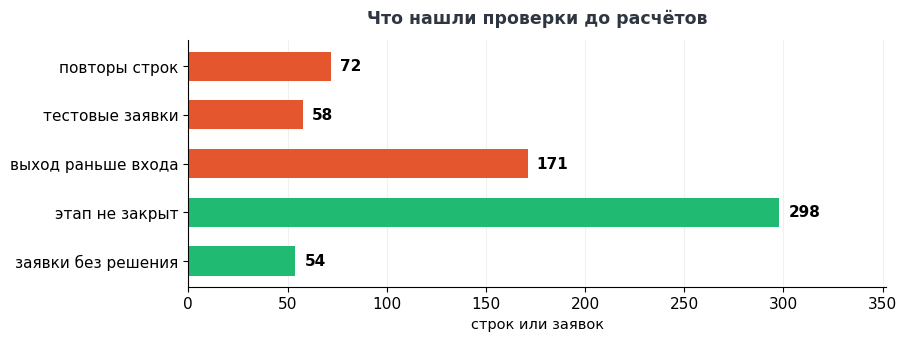

In [8]:
дефекты = запрос("""
    SELECT (SELECT count(*) - count(DISTINCT application_id)
              FROM raw_applications)                          AS повторы,
           (SELECT count(DISTINCT application_id) FROM raw_applications
             WHERE is_test OR client_id = 'CL-TEST')          AS тестовые,
           (SELECT count(*) FROM raw_stage_events
             WHERE left_at < entered_at)                      AS время_назад,
           (SELECT count(*) FROM raw_stage_events
             WHERE left_at IS NULL)                           AS не_закрыт,
           (SELECT count(*) FROM (SELECT DISTINCT application_id
                                    FROM raw_applications) a
             LEFT JOIN raw_decisions d USING (application_id)
            WHERE d.application_id IS NULL)                   AS без_решения
""").iloc[0]

подписи = ["повторы строк", "тестовые заявки", "выход раньше входа",
           "этап не закрыт", "заявки без решения"]
значения = [int(дефекты[к]) for к in
            ("повторы", "тестовые", "время_назад", "не_закрыт", "без_решения")]
цвета = [WARN, WARN, WARN, ACC, ACC]

fig, ax = plt.subplots(figsize=(9, 3.2))
ax.barh(подписи[::-1], значения[::-1], color=цвета[::-1], height=.6)
for i, v in enumerate(значения[::-1]):
    ax.text(v + max(значения) * .015, i, str(v), va="center", fontweight="bold")
ax.set_xlim(0, max(значения) * 1.18)
ax.grid(axis="x", alpha=.18)
оформить(ax, "Что нашли проверки до расчётов", "строк или заявок")
plt.show()

### Сколько стоит пропустить проверку

Ответ на этот вопрос и есть аргумент в пользу чистки. Считаем конверсию
в выдачу дважды: как есть и после отсева повторов и служебных записей.

In [9]:
%%sql
SELECT
    round(100.0 * (SELECT count(*) FROM raw_disbursements)
                / (SELECT count(*) FROM raw_applications), 1)          AS "Как есть, %",
    round(100.0 * (SELECT count(DISTINCT d.application_id)
                     FROM raw_disbursements d
                     JOIN (SELECT DISTINCT application_id
                             FROM raw_applications
                            WHERE NOT is_test AND client_id <> 'CL-TEST') a
                       USING (application_id))
                / (SELECT count(DISTINCT application_id)
                     FROM raw_applications
                    WHERE NOT is_test AND client_id <> 'CL-TEST'), 1)  AS "После проверки, %"

"Как есть, %","После проверки, %"
"49,6","51,4"


Разница — почти два процентных пункта. На отчётном слайде это выглядит как
«конверсия просела», хотя просели только данные.

### Правило чистки живёт в базе

Записывать правило в ячейку тетради — значит через месяц иметь пять разных
правил в пяти отчётах. Правильное место — представление: оно одно, его видят
все инструменты, и панель BI ссылается на него так же, как тетрадь.

In [10]:
%%sql
CREATE OR REPLACE VIEW v_applications_clean AS
SELECT DISTINCT ON (application_id)
       application_id, client_id, product, channel, region,
       amount_requested, submitted_at, source_system
  FROM raw_applications
 WHERE NOT is_test AND client_id <> 'CL-TEST'
 ORDER BY application_id, submitted_at

CREATE VIEW


In [11]:
%%sql
CREATE OR REPLACE VIEW v_stage_events_clean AS
SELECT e.event_id, e.application_id, e.stage, e.entered_at, e.left_at,
       EXTRACT(EPOCH FROM (e.left_at - e.entered_at)) / 3600 AS hours
  FROM raw_stage_events e
  JOIN v_applications_clean a USING (application_id)
 WHERE e.left_at IS NOT NULL AND e.left_at > e.entered_at

CREATE VIEW


In [12]:
%%sql
SELECT
    (SELECT count(*) FROM raw_applications)        AS "Строк было",
    (SELECT count(*) FROM v_applications_clean)    AS "Заявок осталось",
    (SELECT count(*) FROM raw_stage_events)        AS "Событий было",
    (SELECT count(*) FROM v_stage_events_clean)    AS "Событий годно к расчёту"

Строк было,Заявок осталось,Событий было,Событий годно к расчёту
3 672,3 542,14 203,13 516


## Часть 2. Решения на основе данных

Дальше работаем только по чистому слою. Вопросов, которые задаются данным,
на практике четыре, и под каждым — своя команда SQL и своя картинка.

| Вопрос | Что считаем | Команда |
|---|---|---|
| Как устроено распределение? | медиана, среднее, P90 | `percentile_cont` |
| Одинаково ли в группах? | те же меры в разрезе | `GROUP BY` |
| Куда доходят объекты? | воронка этапов | `count(DISTINCT …)` |
| Что меняется во времени? | помесячная динамика | `date_trunc` |

### Распределение: почему среднее обманывает

In [13]:
%%sql
SELECT
    round(avg(hours)::numeric, 1)                                        AS "Среднее, ч",
    round(percentile_cont(0.5) WITHIN GROUP (ORDER BY hours)::numeric, 1) AS "Медиана, ч",
    round(percentile_cont(0.9) WITHIN GROUP (ORDER BY hours)::numeric, 1) AS "P90, ч",
    round(max(hours)::numeric, 1)                                        AS "Максимум, ч",
    count(*)                                                             AS "Событий"
FROM v_stage_events_clean
WHERE stage = 'Андеррайтинг'

"Среднее, ч","Медиана, ч","P90, ч","Максимум, ч",Событий
"46,6","40,6",78,"231,3",2 654


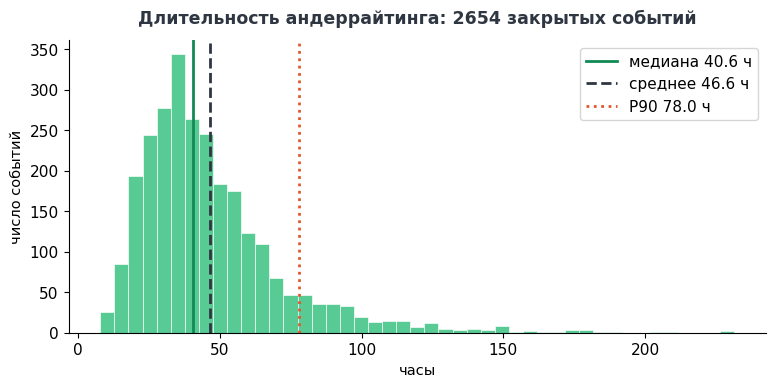

Среднее больше медианы на 6.0 ч — так работает правый хвост.


In [14]:
часы = запрос("""
    SELECT hours AS часы FROM v_stage_events_clean WHERE stage = 'Андеррайтинг'
""")["часы"].astype(float)

fig, ax = plt.subplots(figsize=(9, 3.8))
ax.hist(часы, bins=45, color=ACC, alpha=.75, edgecolor="white", linewidth=.6)
for значение, подпись, цвет, стиль in (
        (часы.median(), f"медиана {часы.median():.1f} ч", "#128a53", "-"),
        (часы.mean(), f"среднее {часы.mean():.1f} ч", INK, "--"),
        (часы.quantile(.9), f"P90 {часы.quantile(.9):.1f} ч", WARN, ":")):
    ax.axvline(значение, color=цвет, linestyle=стиль, linewidth=2, label=подпись)
ax.legend(frameon=True, loc="upper right")
оформить(ax, f"Длительность андеррайтинга: {len(часы)} закрытых событий",
         "часы", "число событий")
plt.show()

print(f"Среднее больше медианы на {часы.mean() - часы.median():.1f} ч — "
      f"так работает правый хвост.")

Хвост коротких и очень длинных случаев тянет среднее вверх, и отчёт по среднему
обещает срок, которого половина заявок не видит. В управленческом разговоре
работают медиана (типичный случай) и P90 (обещание, которое можно дать клиенту).

### Одинаково ли в группах

In [15]:
%%sql
SELECT
    a.channel                                                             AS "Канал",
    count(*)                                                              AS "Событий",
    round(percentile_cont(0.5) WITHIN GROUP (ORDER BY e.hours)::numeric, 1) AS "Медиана, ч",
    round(percentile_cont(0.9) WITHIN GROUP (ORDER BY e.hours)::numeric, 1) AS "P90, ч"
FROM v_stage_events_clean e
JOIN v_applications_clean a USING (application_id)
WHERE e.stage = 'Андеррайтинг'
GROUP BY a.channel
ORDER BY 3 DESC

Канал,Событий,"Медиана, ч","P90, ч"
Партнёрская сеть,571,"54,9","106,9"
Мобильное приложение,904,"37,9","69,1"
Отделение,764,"37,2","66,5"
Корпоративный менеджер,415,"36,7","62,7"


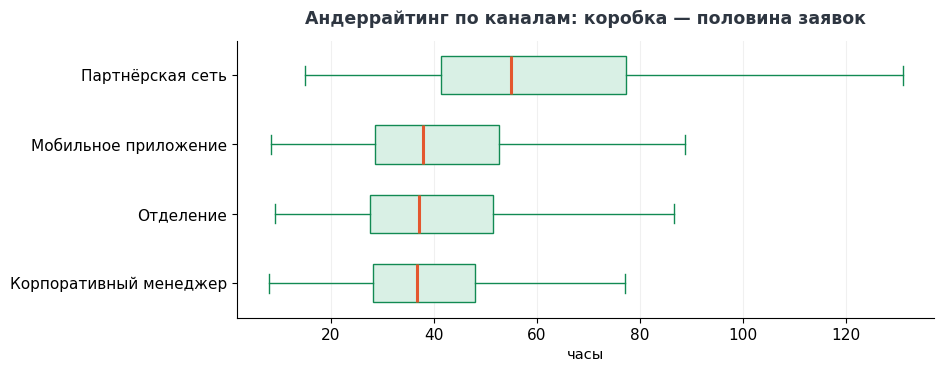

In [16]:
данные = запрос("""
    SELECT a.channel AS канал, e.hours AS часы
      FROM v_stage_events_clean e
      JOIN v_applications_clean a USING (application_id)
     WHERE e.stage = 'Андеррайтинг'
""")
данные["часы"] = данные["часы"].astype(float)
порядок = (данные.groupby("канал")["часы"].median().sort_values().index.tolist())

fig, ax = plt.subplots(figsize=(9, 3.6))
ax.boxplot([данные.loc[данные["канал"] == к, "часы"] for к in порядок],
           vert=False, widths=.55, patch_artist=True, showfliers=False,
           medianprops=dict(color=WARN, linewidth=2.2),
           boxprops=dict(facecolor="#d9f0e5", edgecolor="#128a53"),
           whiskerprops=dict(color="#128a53"), capprops=dict(color="#128a53"))
ax.set_yticklabels(порядок)
ax.grid(axis="x", alpha=.18)
оформить(ax, "Андеррайтинг по каналам: коробка — половина заявок", "часы")
plt.show()

Коробка — половина заявок канала, линия внутри — медиана. Один канал стоит
заметно правее остальных: там андеррайтинг идёт в полтора раза дольше.
Это ещё не вывод, а вопрос к владельцу процесса — состав заявок, режим работы
или способ фиксации времени.

### Куда доходят заявки

In [17]:
%%sql
SELECT
    e.stage                                     AS "Этап",
    count(DISTINCT e.application_id)            AS "Дошло заявок",
    round(100.0 * count(DISTINCT e.application_id) /
          (SELECT count(*) FROM v_applications_clean), 1) AS "Доля, %"
FROM v_stage_events_clean e
GROUP BY e.stage
ORDER BY 2 DESC

Этап,Дошло заявок,"Доля, %"
Приём заявки,3 417,"96,5"
Скоринг,3 306,"93,3"
Андеррайтинг,2 654,"74,9"
Подготовка документов,2 143,"60,5"
Выдача,1 996,"56,4"


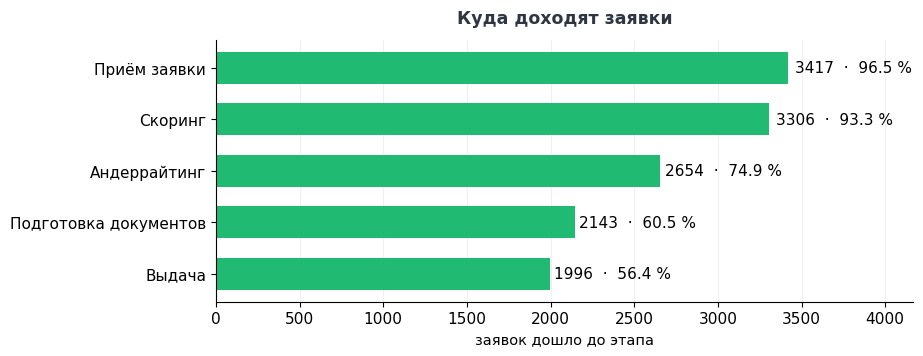

In [18]:
воронка = запрос("""
    SELECT e.stage AS этап,
           count(DISTINCT e.application_id) AS дошло,
           round(100.0 * count(DISTINCT e.application_id) /
                 (SELECT count(*) FROM v_applications_clean), 1) AS доля
      FROM v_stage_events_clean e
     GROUP BY e.stage ORDER BY 2
""")

fig, ax = plt.subplots(figsize=(9, 3.4))
ax.barh(воронка["этап"], воронка["дошло"].astype(int), color=ACC, height=.62)
for i, (v, d) in enumerate(zip(воронка["дошло"].astype(int),
                               воронка["доля"].astype(float))):
    ax.text(v * 1.012, i, f"{v}  ·  {d:.1f} %", va="center")
ax.set_xlim(0, воронка["дошло"].astype(int).max() * 1.22)
ax.grid(axis="x", alpha=.18)
оформить(ax, "Куда доходят заявки", "заявок дошло до этапа")
plt.show()

### Что меняется во времени

Последний месяц в выгрузке почти всегда неполный: данные собраны в середине
периода. Сравнивать его с предыдущими нельзя — падение на графике будет
не про процесс, а про дату выгрузки.

In [19]:
%%sql
SELECT
    to_char(date_trunc('month', a.submitted_at), 'YYYY-MM')   AS "Месяц",
    count(*)                                                  AS "Заявок",
    round(100.0 * count(d.application_id)
          FILTER (WHERE d.decision = 'Одобрено') / count(*), 1) AS "Одобрено, %"
FROM v_applications_clean a
LEFT JOIN raw_decisions d USING (application_id)
GROUP BY 1
ORDER BY 1

Месяц,Заявок,"Одобрено, %"
2025-01,447,"49,4"
2025-02,469,51
2025-03,502,"51,8"
2025-04,524,"49,6"
2025-05,536,"50,4"
2025-06,505,"52,9"
2025-07,517,"51,1"
2025-08,42,"45,2"


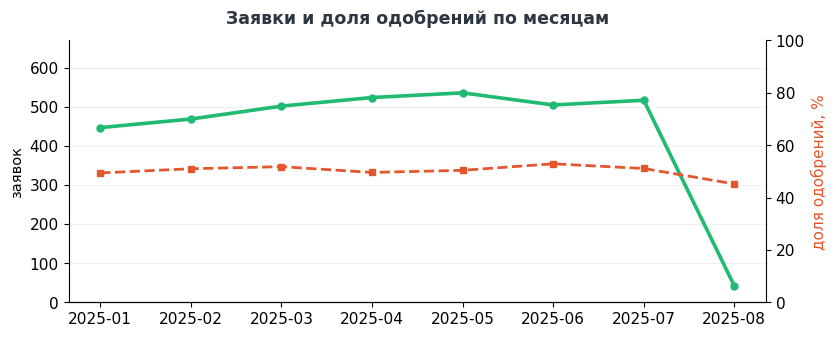

Последний месяц: 2025-08 — проверьте по дате выгрузки, полный ли он.


In [20]:
месяцы = запрос("""
    SELECT to_char(date_trunc('month', a.submitted_at), 'YYYY-MM') AS месяц,
           count(*) AS заявок,
           round(100.0 * count(d.application_id)
                 FILTER (WHERE d.decision = 'Одобрено') / count(*), 1) AS одобрено
      FROM v_applications_clean a
      LEFT JOIN raw_decisions d USING (application_id)
     GROUP BY 1 ORDER BY 1
""")

fig, ax = plt.subplots(figsize=(9, 3.4))
ax.plot(месяцы["месяц"], месяцы["заявок"].astype(int), color=ACC,
        linewidth=2.6, marker="o", markersize=5)
ax.set_ylim(0, месяцы["заявок"].astype(int).max() * 1.25)
ax.grid(axis="y", alpha=.18)
оформить(ax, "Заявки и доля одобрений по месяцам", None, "заявок")

вторая = ax.twinx()
вторая.plot(месяцы["месяц"], месяцы["одобрено"].astype(float), color=WARN,
            linewidth=2, linestyle="--", marker="s", markersize=4)
вторая.set_ylabel("доля одобрений, %", color=WARN)
вторая.set_ylim(0, 100)
вторая.spines[["top", "left"]].set_visible(False)
plt.show()

print("Последний месяц:", месяцы.iloc[-1]["месяц"],
      "— проверьте по дате выгрузки, полный ли он.")

## Что из этого следует

Разведочный анализ заканчивается не графиком, а двумя списками.

**Решения, которые можно принимать уже сейчас**

| Наблюдение | Решение |
|---|---|
| Один канал вдвое медленнее остальных на одном этапе | разбирать этот этап в этом канале, а не «ускорять конвейер» |
| Среднее заметно выше медианы | в отчётности перейти на медиану и P90 |
| Два процентных пункта конверсии потеряны из-за некорректных значений | закрепить правило чистки представлением и считать всем от него |

**Вопросы владельцу процесса** — то, на что данные ответа не дают:

- события с выходом раньше входа — сбой выгрузки или ручные правки?
- незакрытые этапы — заявки в работе или потерянные передачи?
- заявки без решения — то же самое, но между двумя системами;
- полон ли последний месяц выгрузки.

## Куда дальше

- Итоговый запрос переносится в панель BI — это кейс
  [`конвейер_sql.ipynb`](конвейер_sql.ipynb).
- Те же операции в SQL и в pandas, рядом и со сверкой результатов —
  [`памятка_sql_pandas.ipynb`](памятка_sql_pandas.ipynb).
- Тот же анализ, но запросом обычными словами, делает агент — кейс
  [`../2.7_кейс_отчёт_агента/2.7.1_отчёт_по_запросу.ipynb`](../2.7_кейс_отчёт_агента/2.7.1_отчёт_по_запросу.ipynb).